# Módulo HANK (semana 11, mazo 6) — Heterogeneidad: por qué el agente representativo pierde el mecanismo

**Curso complementario · puremacro**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. **Resolver el modelo de Aiyagari (1994)** de mercados incompletos en equilibrio
   estacionario con `puremacro.vfi` y leer la **distribución de riqueza** que produce.
2. Calcular la **propensión marginal a consumir (MPC)** hogar por hogar y ver que una
   **minoría** (≈2% de la población) vive **al día ("mano a boca")** con MPC cercana a 1 —
   y que esa minoría, con un solo activo, resulta demasiado pequeña frente a los datos.
3. **Confrontar** un hecho fiscal empírico —la respuesta del PIB a los choques tributarios
   narrativos de Romer–Romer— con la predicción del **agente representativo**, que con
   MPC ≈ 0 no puede generarla *por la vía del consumo*.
4. Entender cómo **HANK** (Kaplan–Moll–Violante 2018; Auclert 2019) racionaliza el hecho:
   las MPC altas de los hogares restringidos reactivan el **mecanismo** que el agente
   representativo promedia y pierde.

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), leyendo datos locales del bundle: sin conexión y sin costo.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

## 1. El gancho: un hecho fiscal que el agente representativo no puede generar

El caballito de batalla del RBC/DSGE es el **agente representativo (RA)**: un solo hogar
de vida infinita, con mercados completos, que **suaviza el consumo**. En ese mundo una
transferencia de suma fija transitoria casi no mueve el consumo agregado: por la renta
permanente (o la equivalencia ricardiana), la MPC de un peso extra es apenas la anualidad
$\;r/(1+r)\approx 0$ — **casi todo se ahorra**. En consecuencia, los multiplicadores
fiscales del RA rara vez superan 1.

Los **datos** dicen otra cosa. Retomemos los choques fiscales **narrativos** de
Romer–Romer y su efecto sobre el PIB real, con una
**proyección local** de Jordà (`puremacro.lp.lp_hac`).

In [2]:
from puremacro.lp import lp_hac

tax = pd.read_csv(DATA / "tax14_narrative_tax_shocks.csv").rename(columns={"date": "q"})
gdp = pd.read_csv(DATA / "GDPC1.csv")
gdp["q"] = pd.PeriodIndex(pd.to_datetime(gdp["observation_date"]), freq="Q").astype(str)
gdp = gdp.rename(columns={"GDPC1": "gdp"})[["q", "gdp"]]

fis = tax.merge(gdp, on="q", how="inner").sort_values("q").reset_index(drop=True)
fis["y"] = 100.0 * np.log(fis["gdp"])                     # log PIB real, en %
# rr_exog: cambio tributario exógeno de Romer–Romer, medido en % del PIB.
irf = lp_hac(fis, y="y", x="rr_exog", horizons=range(0, 17), n_lags=4)  # respuesta a +1% del PIB

peak = irf.loc[irf["beta"].idxmin()]
sig = irf.loc[irf["hi"] < 0, "h"].astype(int).tolist()      # horizontes con IC 90% bajo cero
print(f"muestra: {fis['q'].iloc[0]}–{fis['q'].iloc[-1]}  ({len(fis)} trimestres)")
print(f"efecto máximo sobre el PIB: {peak['beta']:.2f}%  en h={int(peak['h'])}  (t={peak['t']:.1f})")
print(f"horizontes significativos al 90%: h = {sig}")
assert peak["beta"] < -1.0        # el PIB cae >1% tras un alza de impuestos de 1% del PIB

muestra: 1947Q1–2007Q4  (244 trimestres)
efecto máximo sobre el PIB: -1.98%  en h=10  (t=-2.3)
horizontes significativos al 90%: h = [9, 10, 11, 12, 13, 14, 15, 16]


### El hecho, en una figura
Un aumento exógeno de impuestos de **1% del PIB** contrae el PIB **cerca de dos puntos**
($-1.98\%$ en el pico, $h=10$) y de forma **persistente**: el intervalo al 90% queda por
debajo de cero desde $h=9$ hasta el final del horizonte estimado. **Ese es el orden de
magnitud que buscamos explicar.**

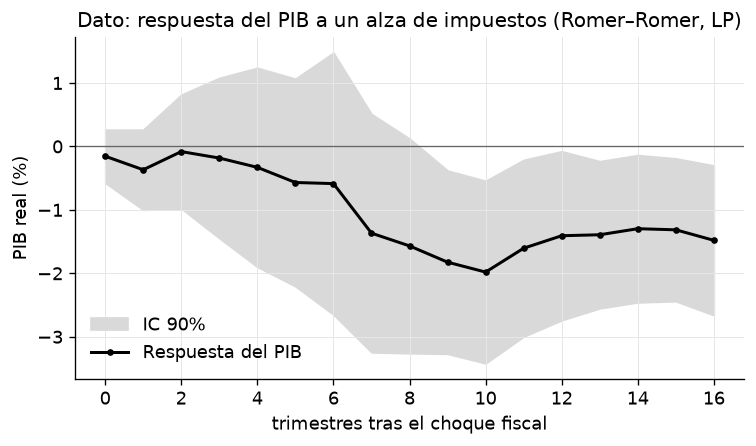

In [3]:
cols = _nbstyle.palette(2)
fig, ax = plt.subplots(figsize=(7.2, 3.7))
ax.fill_between(irf["h"], irf["lo"], irf["hi"], color="0.85", label="IC 90%")
ax.plot(irf["h"], irf["beta"], color=cols[0], lw=1.8, marker="o", ms=3, label="Respuesta del PIB")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("trimestres tras el choque fiscal")
ax.set_ylabel("PIB real (%)")
ax.set_title("Dato: respuesta del PIB a un alza de impuestos (Romer–Romer, LP)")
ax.legend(loc="lower left")
plt.show()

### Dos cautelas antes de sacar conclusiones
1. Esto es un **multiplicador de impuestos**, no de gasto, y los impuestos de Romer–Romer
   son **distorsionantes**: una parte de esa caída un modelo de agente representativo *sí*
   la produce, por el lado de la **oferta** (sustitución intertemporal, oferta laboral), sin
   necesidad de MPC altas. Para el **gasto**, la evidencia sigue en disputa: Ramey y Zubairy
   (2018) estiman multiplicadores por debajo de 1 con y sin holgura.
2. La evidencia realmente incómoda para el agente representativo es **microeconómica**, y es
   la que usa el mazo Slides06: la fracción de un ingreso transitorio que se consume en el
   mismo trimestre está entre **0.2 y 0.6** (reembolsos fiscales de 2001 y 2008,
   transferencias de 2020; ≈**0.5 al año** en las loterías noruegas), frente a la anualidad
   $r/(1+r)\approx 0.005$ trimestral de la renta permanente. Ahí la brecha no es de
   calibración: son dos órdenes de magnitud.

El resto de la lección construye el modelo que puede, al menos, ir en esa dirección.

## 2. Teoría breve: el modelo de Aiyagari (1994)

Aiyagari sustituye al agente representativo por un **continuo de hogares** que enfrentan:
- **Riesgo idiosincrático** de productividad laboral $z$, un AR(1) (aquí discretizado con
  Tauchen): a veces te va bien, a veces mal, y **no puedes asegurarte** contra ello.
- Un **límite de endeudamiento** $a \ge 0$: no puedes pedir prestado indefinidamente.

El hogar resuelve $\;\max\; \mathbb{E}\sum_t \beta^t u(c_t)\;$ sujeto a
$\;c_t + a_{t+1} = w\,e^{z_t} + (1+r)\,a_t,\; a_{t+1}\ge 0$. Con mercados incompletos
aparece el **ahorro precautorio**: los hogares acumulan un colchón de activos para
amortiguar los golpes de ingreso. En equilibrio, la tasa $r$ iguala la oferta de capital
de los hogares con la demanda de una empresa Cobb–Douglas.

La consecuencia clave: el modelo genera una **distribución de riqueza no degenerada** y,
con ella, una **distribución de MPC**. Los hogares pegados a la restricción consumen casi
todo el peso extra (MPC → 1 ante un maná marginal); los ricos, con colchón, bajan hacia el
**piso de previsión perfecta** $\kappa = 1-[\beta(1+r)]^{1/\gamma}/(1+r)$ —que aquí vale
$0.030$— y **nunca llegan a cero**. El agente representativo colapsa todo eso a un
**promedio** — y ahí pierde el mecanismo.

`puremacro.vfi` trae este modelo listo en `aiyagari_steady_state` (iteración de la función
de valor + distribución estacionaria + equilibrio general, en NumPy puro).

**Calibración: la del mazo, no otra.** Usamos **exactamente** los parámetros con los que el
mazo Slides06 produce sus figuras (`figuras_curso.py::aiyagari_a6`): Tauchen con **7**
estados, $\gamma=2$ (CRRA, **no** log — el valor por omisión de `aiyagari_steady_state` es
$\gamma=1$, que es *otro* modelo), $\beta=0.96$, $\alpha=0.36$, $\delta=0.08$, $\rho=0.90$,
$\sigma=0.20$, malla de 1000 nodos hasta $a_{\max}=100$.

**El método no es idéntico y conviene decirlo.** El mazo resuelve el hogar por *grillas
endógenas* sobre una malla **curvada** y arma la distribución por el método de la
**lotería**; `aiyagari_steady_state` usa iteración de valor de **elección discreta** sobre
una malla **uniforme**. El propio mazo documenta que ambas rutas dan los **mismos precios y
agregados** —EGM: $r^{*}=2.034\%$, $K/Y=3.588$, Gini $0.5340$; VFI con $n_a=1000$:
$2.032\%$, $3.589$, $0.5339$— y que **sólo la política continua sirve para propensiones**.
Por eso aquí tomamos de esta celda los **precios y agregados**, y en la siguiente
reconstruimos el bloque de hogares con la receta del mazo para medir las MPC.

*Costo de cómputo:* esta celda tarda ~30 s en una máquina de escritorio y bastante más en
una laptop modesta. Es el precio de reproducir el mazo; no bajes `n_z` ni `n_a` sin
declarar que las cifras dejan de ser las suyas.

In [4]:
from puremacro.vfi.examples import aiyagari_steady_state
from puremacro.vfi import weighted_quantile, solve_egm, lottery_distribution

# Los parámetros EXACTOS de figuras_curso.py::aiyagari_a6 (mazo Slides06).
A6 = dict(alpha=0.36, delta=0.08, beta=0.96, gamma=2.0,
          rho=0.90, sigma=0.20, n_z=7, n_a=1000, a_max=100.0)

res = aiyagari_steady_state(**A6)                        # GE estacionario de Aiyagari
eq, prob = res["equilibrium"], res["equilibrium"].problem
a_vfi = np.asarray(prob.a_grid)                          # malla UNIFORME de la VFI
z_grid = np.asarray(prob.z_grid); P_z = np.asarray(prob.P_z)
mu_vfi = np.asarray(eq.distribution, dtype=float)        # distribución de la VFI
r, w = res["r"], res["w"]
KY = res["K"] / res["Y"]

print(f"tasa de equilibrio r = {100*r:.3f}%   salario w = {w:.3f}")
print(f"capital K = {res['K']:.2f}   producto Y = {res['Y']:.2f}   K/Y = {KY:.3f}")
print(f"Gini de riqueza = {res['wealth_gini']:.4f}")
print("mazo Slides06 — EGM: r=2.034%, K/Y=3.588, Gini=0.5340 | "
      "VFI n_a=1000: r=2.032%, K/Y=3.589, Gini=0.5339")
print(f"y el agente representativo con el mismo β: r = {100*(1/A6['beta'] - 1):.2f}%, "
      f"K/Y = {A6['alpha']/(1/A6['beta'] - 1 + A6['delta']):.2f}  ← ni el agregado le sale igual")

# El contrato con el mazo: las tres cifras insignia, dígito a dígito.
assert abs(100 * r - 2.034) < 0.05,          "r debe ser ~2.03% (mazo Slides06)"
assert abs(KY - 3.588) < 0.02,               "K/Y debe ser ~3.59 (mazo Slides06)"
assert abs(res["wealth_gini"] - 0.534) < 0.01, "el Gini debe ser ~0.534 (mazo Slides06)"

tasa de equilibrio r = 2.032%   salario w = 1.313
capital K = 8.50   producto Y = 2.37   K/Y = 3.588
Gini de riqueza = 0.5339
mazo Slides06 — EGM: r=2.034%, K/Y=3.588, Gini=0.5340 | VFI n_a=1000: r=2.032%, K/Y=3.589, Gini=0.5339
y el agente representativo con el mismo β: r = 4.17%, K/Y = 2.96  ← ni el agregado le sale igual


### Riqueza y MPC hogar por hogar
La **MPC** es la fracción de un maná transitorio $\tau$ que el hogar consume hoy:
$\;\text{MPC}(a,z) = [\,c(a+\tau/(1+r),z) - c(a,z)\,]/\tau$ (el maná entra como activo
extra porque el activo rinde $1+r$). Tomamos el mismo $\tau=0.10$ del mazo.

**Aquí hay una trampa de método que el mazo declara y hay que respetar.** La política que
devuelve la VFI de **elección discreta** es una **escalera**: $a'$ sólo puede aterrizar en
un nodo de la malla, así que la MPC medida sobre ella toma un puñado de valores y lo que se
promedia es la malla, no el modelo. Con la malla gruesa que usaba una versión anterior de
esta lección (los valores por omisión: $n_z=5$, $n_a=150$ y, de paso, $\gamma=1$) la MPC
sólo tomaba **tres** valores —$0$, $0.03$ y $1$— y
ese artefacto inflaba la cifra hasta $\approx0.27$: justo dentro del rango de los datos, y
por pura casualidad numérica. El mazo Slides06 lo documenta y prohíbe reportarlo.

Por eso reconstruimos aquí el bloque de hogares **con la receta del mazo**, a los precios
$(r,w)$ que ya resolvimos:
1. **Malla curvada**, $a_i = a_{\max}u_i^{3}$: los nodos se apretujan junto a la
   restricción, que es donde vive toda la curvatura de la política. (En la malla uniforme
   de la celda anterior el paso es $0.10$, *más grande que el propio maná*: ahí no se puede
   medir una MPC marginal ni distinguirla de la de $\tau=0.10$.)
2. Política **continua** por el método de las mallas endógenas (`solve_egm`); la función de
   consumo es estrictamente cóncava (Carroll–Kimball).
3. Distribución estacionaria por el método de la **lotería** (`lottery_distribution`),
   coherente con esa política continua.

Con eso, las cifras del mazo salen **dígito a dígito** — y podemos comprobarlo en vez de
citarlo.

In [5]:
# Bloque de hogares con la receta del mazo: malla curvada + EGM + lotería, a (r, w) del GE.
u_grid = np.linspace(0.0, 1.0, A6["n_a"])
a_grid = A6["a_max"] * u_grid ** 3.0               # malla CURVADA (exponente 3, como el mazo)
egm = solve_egm(a_grid, z_grid, w * np.exp(z_grid), P_z,
                beta=A6["beta"], r=r, gamma=A6["gamma"])
C = egm.c                                          # (n_a, n_z), continua en a
mu = np.asarray(lottery_distribution(egm.aprime, a_grid, P_z), dtype=float)
mu_a = mu.sum(axis=1)                              # distribución marginal de riqueza


def mpc_de(tau):
    """MPC(a,z) ante un maná transitorio de tau bienes (entra como tau/(1+r) de activo)."""
    m = np.empty_like(C)
    for j in range(z_grid.size):
        m[:, j] = (np.interp(a_grid + tau / (1.0 + r), a_grid, C[:, j]) - C[:, j]) / tau
    return m


tau = 0.10                                         # el mismo maná transitorio del mazo
mpc = mpc_de(tau)
avg_mpc = float((mu * mpc).sum())                  # MPC promedio ponderada por la población
ra_mpc = r / (1.0 + r)                             # anualidad de la renta permanente (β(1+r)=1)
kappa = 1.0 - (A6["beta"] * (1.0 + r)) ** (1.0 / A6["gamma"]) / (1.0 + r)   # piso de PF
share_hi = float(mu[mpc > 0.3].sum())              # fracción con MPC alta (mano a boca)
share_mid = float(mu[mpc > 0.10].sum())            # fracción con MPC por encima de 0.10

print(f"MPC media, maná τ=0.10   = {avg_mpc:.4f}   (mazo Slides06: 0.0832)")
print(f"MPC media, maná marginal = {float((mu*mpc_de(1e-6)).sum()):.4f}   (mazo: 0.0938)")
print(f"MPC media, maná τ=1.00   = {float((mu*mpc_de(1.0)).sum()):.4f}   (mazo: 0.0688)"
      f"  ← baja con τ porque c es cóncava")
print(f"anualidad r/(1+r) = {ra_mpc:.4f}   piso de previsión perfecta κ = {kappa:.4f}"
      f"   (mazo: 0.0199 y 0.0300)")
print(f"cociente MPC media / anualidad = {avg_mpc/ra_mpc:.1f} veces "
      f"(y {avg_mpc/kappa:.1f} veces el piso κ)")
print(f"en la esquina, con z bajo: MPC = {mpc[0, 0]:.2f} con τ=0.10 y "
      f"{mpc_de(1e-6)[0, 0]:.2f} en el margen   (mazo: 0.72 y 1)")
print(f"fracción de hogares con MPC > 0.30 = {share_hi:.3f}   con MPC > 0.10 = {share_mid:.3f}")
print(f"masa que elige la esquina a'=0     = "
      f"{float(mu[egm.aprime <= a_grid[0] + 1e-9].sum()):.4f}   (mazo: 0.0203)")
assert abs(avg_mpc - 0.0832) < 0.002   # la MPC media del mazo, reproducida aquí
assert 3.0 < avg_mpc / ra_mpc < 6.0    # el promedio heterogéneo cuadruplica la anualidad
assert avg_mpc < 0.15                  # ...y aun así se queda MUY corto frente a los datos

# Control de método (pregunta 4): la MISMA solución de equilibrio, leída sobre la ESCALERA
# de la VFI. Mismos precios, misma calibración; la MPC cambia por completo.
ap_esc = a_vfi[np.asarray(eq.solution.policy_aprime, dtype=int)]   # OJO: son ÍNDICES de la malla
c_esc = w * np.exp(z_grid)[None, :] + (1.0 + r) * a_vfi[:, None] - ap_esc
mpc_esc = np.empty_like(c_esc)
for j in range(z_grid.size):
    mpc_esc[:, j] = (np.interp(a_vfi + tau / (1.0 + r), a_vfi, c_esc[:, j]) - c_esc[:, j]) / tau
print(f"[control] la misma MPC medida sobre la escalera de la VFI = "
      f"{float((mu_vfi*mpc_esc).sum()):.3f}, y sólo toma "
      f"{np.unique(np.round(mpc_esc, 3)).size} valores distintos (mazo: 0.100)")

MPC media, maná τ=0.10   = 0.0833   (mazo Slides06: 0.0832)
MPC media, maná marginal = 0.0938   (mazo: 0.0938)
MPC media, maná τ=1.00   = 0.0688   (mazo: 0.0688)  ← baja con τ porque c es cóncava
anualidad r/(1+r) = 0.0199   piso de previsión perfecta κ = 0.0300   (mazo: 0.0199 y 0.0300)
cociente MPC media / anualidad = 4.2 veces (y 2.8 veces el piso κ)
en la esquina, con z bajo: MPC = 0.72 con τ=0.10 y 1.00 en el margen   (mazo: 0.72 y 1)
fracción de hogares con MPC > 0.30 = 0.027   con MPC > 0.10 = 0.166
masa que elige la esquina a'=0     = 0.0204   (mazo: 0.0203)
[control] la misma MPC medida sobre la escalera de la VFI = 0.100, y sólo toma 3 valores distintos (mazo: 0.100)


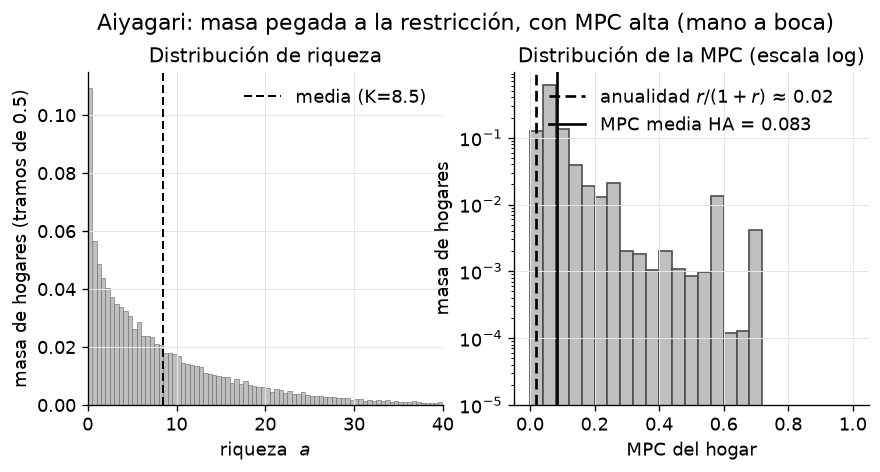

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.6))

# La malla es CURVADA: la masa por nodo no es una densidad. Agrupamos en tramos iguales.
bins = np.linspace(0, 40, 81)
masa, _ = np.histogram(a_grid, bins=bins, weights=mu_a)
K_mu = float((mu * a_grid[:, None]).sum())
ax[0].bar(bins[:-1], masa, width=np.diff(bins), align="edge", color="0.75",
          edgecolor="0.35", lw=0.3)
ax[0].axvline(K_mu, color=cols[0], lw=1.2, ls=(0, (4, 2)), label=f"media (K={K_mu:.1f})")
ax[0].set_xlim(0, 40); ax[0].set_xlabel("riqueza  $a$")
ax[0].set_ylabel("masa de hogares (tramos de 0.5)")
ax[0].set_title("Distribución de riqueza"); ax[0].legend(loc="upper right")

wl = mpc.reshape(-1); ww = mu.reshape(-1)
ax[1].hist(wl, bins=np.linspace(0, 1, 26), weights=ww, color="0.75", edgecolor="0.3")
ax[1].axvline(ra_mpc, color=cols[0], lw=1.6, ls=(0, (4, 2)),
              label=f"anualidad $r/(1+r)$ ≈ {ra_mpc:.02f}")
ax[1].axvline(avg_mpc, color="0.0", lw=1.6, label=f"MPC media HA = {avg_mpc:.3f}")
ax[1].set_xlabel("MPC del hogar"); ax[1].set_ylabel("masa de hogares")
ax[1].set_yscale("log"); ax[1].set_ylim(bottom=1e-5)   # la cola alta es pequeña pero decisiva
ax[1].set_title("Distribución de la MPC (escala log)"); ax[1].legend(loc="upper center")
fig.suptitle("Aiyagari: masa pegada a la restricción, con MPC alta (mano a boca)", y=1.02)
plt.show()

### Lectura
La izquierda muestra una montaña de masa **pegada a la restricción** $a\approx 0$: el primer
tramo, $a<0.5$, concentra el $11\%$ de los hogares y un $2.0\%$ elige la esquina $a'=0$. La
derecha traduce eso a comportamiento: hay una cola de hogares con **MPC alta** —$0.72$ en la
esquina con este maná de $\tau=0.10$, y exactamente $1$ ante un maná *marginal*—, muy lejos
de la anualidad de la renta permanente (línea discontinua). Nota de lectura de la figura: la
malla es curvada, así que la masa **por nodo** no es una densidad; el panel izquierdo agrupa
la masa en tramos iguales de $0.5$.

Ahora las magnitudes, que es donde el modelo se juega la vida. El promedio poblacional
(línea negra) es $\approx0.083$: **cuatro veces** la anualidad $r/(1+r)=0.020$ del hogar de
renta permanente (y $2.8$ veces el piso $\kappa=0.030$ que corresponde a estos precios),
lo cual es mucho — pero **muy por debajo** de lo que reportan los datos micro. Ojo con la
periodicidad al comparar: este modelo es **anual** ($\beta=0.96$), y el dato anual
comparable es $\approx0.5$ (loterías noruegas); el rango $0.2$–$0.6$ es **trimestral** y por
tanto una cota todavía más exigente al año. Sólo un $2.7\%$ de los hogares tiene MPC por
encima de $0.30$.

Ése es exactamente el veredicto del mazo Slides06, y conviene decirlo sin adornos: el
Aiyagari de **un solo activo** va en la dirección correcta y **se queda corto**. Le pasa lo
mismo con la desigualdad — Gini $0.534$ contra al menos $0.74$ en los datos — y por la
misma razón: no tiene con qué generar suficientes hogares sin colchón. La versión de **dos
activos** de Kaplan–Moll–Violante (riqueza ilíquida → *ricos* de mano a boca) es la que
cierra las dos brechas a la vez.

## 3. El experimento de transferencia: RA vs. heterogeneidad

Repartamos una transferencia de suma fija idéntica a todos y midamos cuánto **consumo
agregado** genera (el efecto directo de primera ronda, à la Auclert 2019). En el RA se
ahorra casi todo; con heterogeneidad, **los hogares de mano a boca lo gastan**. Pero ojo con
la aritmética: los de la esquina son tan pocos que no bastan por sí solos —aportan una
sexta parte de la respuesta—, y lo que hace el trabajo es toda la **mitad más pobre**.
Veamos **quién** hace ese gasto.

In [7]:
mpc_a = (mu * mpc).sum(axis=1) / np.where(mu_a > 0, mu_a, 1.0)   # E[MPC | a]: MPC media por riqueza
contrib_a = mu_a * mpc_a                                          # aporte de cada nivel de riqueza (suma = avg_mpc)

med = float(weighted_quantile(mu.reshape(-1),
                              np.broadcast_to(a_grid[:, None], mu.shape).reshape(-1), [0.5])[0])
share_bottom = float(contrib_a[a_grid <= med].sum() / contrib_a.sum())   # aporte de la mitad más pobre
share_h2m = float((mu * mpc)[mpc > 0.3].sum() / avg_mpc)                 # aporte de los de mano a boca

print(f"riqueza mediana = {med:.2f}   (mazo Slides06: 5.59; media K = {K_mu:.2f})")
print(f"respuesta del consumo agregado a la transferencia:  RA = {ra_mpc:.03f}   HA = {avg_mpc:.03f}")
print(f"de esa respuesta HA, la mitad MÁS POBRE aporta el {100*share_bottom:.0f}%")
print(f"y los de mano a boca (MPC>0.30, {100*share_hi:.1f}% de los hogares) aportan el "
      f"{100*share_h2m:.0f}%")

riqueza mediana = 5.59   (mazo Slides06: 5.59; media K = 8.49)
respuesta del consumo agregado a la transferencia:  RA = 0.020   HA = 0.083
de esa respuesta HA, la mitad MÁS POBRE aporta el 73%
y los de mano a boca (MPC>0.30, 2.7% de los hogares) aportan el 18%


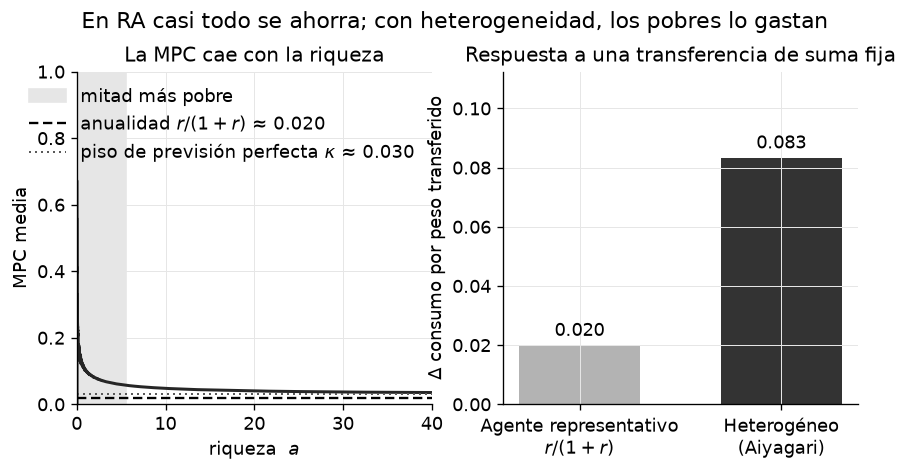

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.6))

ax[0].plot(a_grid, mpc_a, color="0.15", lw=1.8)
ax[0].axvspan(0, med, color="0.9", label="mitad más pobre")
ax[0].axhline(ra_mpc, color=cols[0], lw=1.4, ls=(0, (4, 2)),
              label=f"anualidad $r/(1+r)$ ≈ {ra_mpc:.03f}")
ax[0].axhline(kappa, color="0.35", lw=1.2, ls=(0, (1, 2)),
              label=f"piso de previsión perfecta $\\kappa$ ≈ {kappa:.03f}")
ax[0].set_xlim(0, 40); ax[0].set_ylim(0, 1)
ax[0].set_xlabel("riqueza  $a$"); ax[0].set_ylabel("MPC media")
ax[0].set_title("La MPC cae con la riqueza"); ax[0].legend(loc="upper right")

bars = ax[1].bar(["Agente representativo\n$r/(1+r)$", "Heterogéneo\n(Aiyagari)"],
                 [ra_mpc, avg_mpc], color=["0.7", "0.2"], width=0.6)
ax[1].bar_label(bars, fmt="%.3f", padding=3)
ax[1].set_ylabel("Δ consumo por peso transferido")
ax[1].set_ylim(0, avg_mpc * 1.35)
ax[1].set_title("Respuesta a una transferencia de suma fija")
fig.suptitle("En RA casi todo se ahorra; con heterogeneidad, los pobres lo gastan", y=1.02)
plt.show()

### La moraleja HANK
Kaplan, Moll y Violante (2018) muestran que este es **el** canal que le falta al DSGE de
agente representativo: al reintroducir hogares heterogéneos con MPC altas, la política
fiscal (y la monetaria, vía ingreso) recupera fuerza. Auclert (2019) formaliza que el
efecto agregado de una transferencia es esencialmente la **MPC promedio** ponderada por
quién la recibe. Con las cifras de esta lección la lectura es nítida y hay que sostenerla
entera: el Aiyagari básico *sí* cuadruplica la anualidad del hogar de renta permanente
($0.083$ contra $0.020$) y *aun así* **subestima** la MPC de los datos ($\approx0.5$ al
año) y la cola rica (Gini $0.534$ contra $\ge0.74$).
La versión de dos activos de KMV (riqueza ilíquida → "ricos de mano a boca") es la que la
acerca a los datos.

## 4. Preguntas para pensar
1. **¿Quién absorbe una recesión?** En este modelo, ¿qué hogares recortan más su consumo
   cuando cae el ingreso: los de la montaña en $a\approx 0$ o los de la cola rica? ¿Por
   qué la desigualdad de riqueza convierte a una recesión agregada en un golpe muy
   desigual?
2. Con el **mismo** $\beta$, el agente representativo ni siquiera acierta el agregado: su
   tasa es $1/\beta-1=4.17\%$ y su $K/Y=\alpha/(r+\delta)=2.96$, contra $2.03\%$ y $3.59$
   aquí. ¿Por qué el ahorro precautorio empuja $K$ hacia arriba y $r$ hacia abajo? Y
   supongamos que **recalibramos** $\beta$ para que el RA acierte $K$ exactamente: ¿por qué
   **seguiría fallando** en el multiplicador fiscal? ¿Qué momento de la distribución —no la
   media— es el que importa para el mecanismo?
3. Una transferencia **más grande** tiene una MPC media **menor** que una pequeña: la celda
   de arriba ya lo midió —$0.094$ en el margen, $0.083$ con $\tau=0.10$ y $0.069$ con
   $\tau=1.0$ (dos tercios del ingreso laboral medio, $wL=1.52$)—. ¿Por qué? (Pista: piensa
   en el hogar que, con el dinero extra, logra despegarse de la restricción $a\ge 0$.)
4. **El precio de la malla.** El `[control]` de la celda de MPC lo muestra con números:
   sobre *la misma* solución de equilibrio, la política escalera de la VFI da una MPC media
   de $0.100$ (y sólo tres valores distintos) frente al $0.083$ de la política continua.
   ¿Por qué los agregados ($r$, $K/Y$, Gini) casi no se enteran de la malla y la MPC sí?
   ¿Qué te dice eso sobre qué estadísticos puedes reportar desde una VFI discreta?

### Notas para las preguntas
1. Recortan más los de la montaña en $a\approx0$: no tienen colchón, así que su consumo
   sigue al ingreso casi uno a uno (MPC cerca de 1). Los de la cola rica desahorran y apenas
   mueven su consumo. Por eso una recesión agregada del mismo tamaño produce pérdidas de
   bienestar radicalmente distintas según dónde estés en la distribución — y por eso la
   media del consumo agregado esconde el golpe.
2. El ahorro precautorio añade demanda de activos que no existe en el RA: la oferta de
   capital se desplaza a la derecha, $r$ cae de $4.17\%$ a $2.03\%$ y $K/Y$ sube de $2.96$ a
   $3.59$. Y aun recalibrando $\beta$ para clavar $K$, el multiplicador seguiría fallando:
   no depende de la **media** de la riqueza sino de la **MPC ponderada por quién recibe la
   transferencia**, que es un promedio de una función **cóncava** (la MPC cae con $a$) sobre
   una distribución muy asimétrica. Por Jensen, el promedio de la MPC no es la MPC del
   promedio: el RA evalúa la MPC en $a=K$, donde vale $\approx0.03$, mientras la población
   tiene masa donde vale $0.7$ o más. El momento relevante es la masa en (o cerca de) la
   restricción — en esta solución, la mitad más pobre aporta ~el 73% de la respuesta
   agregada, y los de mano a boca, siendo el 2.7% de los hogares, aportan ~el 18%.
3. Porque la MPC es decreciente en el efectivo disponible y la transferencia grande
   **mueve** al hogar a lo largo de esa curva: el hogar restringido, con el dinero extra, se
   despega de $a\ge0$ y su MPC cae dentro del mismo experimento. La MPC de una transferencia
   de tamaño $\tau$ es el cociente incremental $[c(a+\tau/(1+r))-c(a)]/\tau$, que por
   concavidad es menor cuanto mayor es $\tau$; la MPC "marginal" ($\tau\to0$) es la cota
   superior.
4. Los agregados son **integrales** de la política sobre la distribución, y el error de
   discretización se promedia y casi se cancela; la MPC es una **derivada**, y derivar una
   escalera devuelve la escalera, no la pendiente. Regla práctica: de una VFI de elección
   discreta puedes reportar niveles y agregados ($r$, $K$, $Y$, Gini), pero **no**
   derivadas de la política (MPC, elasticidades) sin una política continua — EGM, o
   interpolación con lotería sobre una malla curvada como la del mazo.

## 5. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "En una frase, ¿por qué la MPC promedio importa para el multiplicador fiscal, y por qué
  el agente representativo la subestima?"
- "¿Qué agrega el modelo de dos activos de Kaplan–Moll–Violante frente al Aiyagari de un
  activo para explicar las MPC altas?"

In [9]:
print(tutor("En una frase, ¿por qué el modelo de agente representativo subestima el "
            "multiplicador fiscal frente a un modelo con hogares heterogéneos (HANK)?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Partimos de un **hecho** fiscal en datos reales (el PIB cae cerca de dos puntos
tras un alza tributaria narrativa de 1% del PIB) y, sobre todo, del hecho **micro** que lo
acompaña: propensiones a consumir de $0.2$–$0.6$ al trimestre que el **agente
representativo**, con MPC ≈ 0, no puede generar. Resolvimos el **Aiyagari** con
`puremacro.vfi` **en la calibración del mazo Slides06** ($r^{*}=2.03\%$, $K/Y=3.59$,
Gini $=0.534$), reconstruimos el bloque de hogares con la receta del mazo (malla curvada +
EGM + lotería), vimos su **distribución de riqueza** y su **distribución de MPC** —con una
cola de hogares de mano a boca— y mostramos, con un experimento de **transferencia**, que la
respuesta del consumo agregado es ~4× la anualidad de la renta permanente porque son los
pobres quienes gastan. Ese es el **mecanismo de HANK** (Aiyagari 1994; Kaplan–Moll–Violante
2018; Auclert 2019): la heterogeneidad no es un detalle contable, es *el* canal. Y el remate
honesto: con **un solo activo** el canal existe pero es demasiado débil —$0.083$ al año
contra $\approx0.5$ anual en los datos—, que es justamente el argumento para pasar a los
**dos activos** de KMV.

### Referencias
- Aiyagari, S. R. (1994). *Uninsured Idiosyncratic Risk and Aggregate Saving.* QJE.
- Kaplan, G., Moll, B. y Violante, G. (2018). *Monetary Policy According to HANK.* AER.
- Auclert, A. (2019). *Monetary Policy and the Redistribution Channel.* AER.